In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

In [5]:
train_path = "/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt"
test_path = "/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt"

train_df = pd.read_csv(train_path, names=column_names)
test_df = pd.read_csv(test_path, names=column_names)

print("شکل (Shape) دیتای ترین:", train_df.shape)
print("شکل (Shape) دیتای تست:", test_df.shape)

شکل (Shape) دیتای ترین: (125973, 43)
شکل (Shape) دیتای تست: (22544, 43)


In [6]:
train_path = "/kaggle/input/nslkdd/KDDTrain+.txt"
test_path = "/kaggle/input/nslkdd/KDDTest+.txt"

In [7]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [8]:
# دیکشنری (Dictionary) که هر نام حمله رو به دسته‌ی اصلیش نگاشت (Map) می‌کنه
attack_mapping = {
    'normal': 'normal',

    # دسته‌ی DoS
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',

    # دسته‌ی Probe
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',

    # دسته‌ی R2L
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'xlock': 'R2L',
    'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'worm': 'R2L',

    # دسته‌ی U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R'
}

# ساخت یک ستون جدید به اسم attack_category بر اساس این نگاشت
train_df['attack_category'] = train_df['label'].map(attack_mapping)
test_df['attack_category'] = test_df['label'].map(attack_mapping)

# چک کردن نتیجه
print(train_df['attack_category'].value_counts())

attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [9]:
print("مقادیر خالی در train:", train_df['attack_category'].isnull().sum())
print("مقادیر خالی در test:", test_df['attack_category'].isnull().sum())

مقادیر خالی در train: 0
مقادیر خالی در test: 0


In [10]:
print(train_df['protocol_type'].value_counts())

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


In [11]:
print(train_df['service'].value_counts().head(15))

service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
ftp          1754
auth          955
Z39_50        862
uucp          780
courier       734
Name: count, dtype: int64


In [12]:
print(train_df['flag'].value_counts())

flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


In [13]:
pd.crosstab(train_df['flag'], train_df['attack_category'])

attack_category,DoS,Probe,R2L,U2R,normal
flag,,,,,
OTH,0,35,0,0,11
REJ,5671,2869,0,0,2693
RSTO,1216,80,46,1,219
RSTOS0,0,103,0,0,0
RSTR,90,2180,5,0,146
S0,34344,153,0,0,354
S1,2,1,1,0,361
S2,5,2,1,0,119
S3,0,1,3,0,45


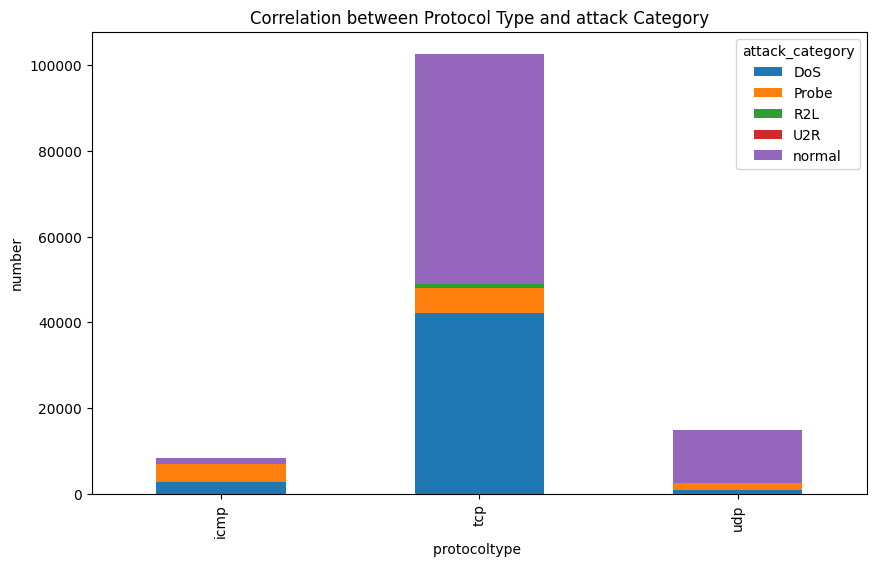

In [14]:
pd.crosstab(train_df['protocol_type'], train_df['attack_category']).plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Correlation between Protocol Type and attack Category')
plt.xlabel('protocoltype ')
plt.ylabel('number')
plt.show()

In [15]:
train_df[['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']].describe()

,duration,src_bytes,dst_bytes,count,srv_count
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,84.107555,27.737888
std,2604.51531,5.870331e+06,4.021269e+06,114.508607,72.635840
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,2.000000,2.000000
50%,0.00000,4.400000e+01,0.000000e+00,14.000000,8.000000
75%,0.00000,2.760000e+02,5.160000e+02,143.000000,18.000000
max,42908.00000,1.379964e+09,1.309937e+09,511.000000,511.000000


In [16]:
train_df.groupby('attack_category')[['duration', 'src_bytes', 'dst_bytes', 'count']].mean()

,duration,src_bytes,dst_bytes,count
attack_category,,,,
DoS,0.006227,1176.321162,169.201537,178.090034
Probe,2074.858185,385679.838367,181074.911805,77.052248
R2L,633.417085,307727.300503,81822.026131,1.297487
U2R,80.942308,906.230769,5141.961538,5.807692
normal,168.587396,13133.279331,4329.685223,22.517945


In [17]:
# بخش یک: تبدیل ستون‌های دسته‌ای به عدد
categorical_columns = ['protocol_type', 'service', 'flag']
train_encoded = pd.get_dummies(train_df, columns=categorical_columns)
test_encoded = pd.get_dummies(test_df, columns=categorical_columns)

# بخش دو: هماهنگ کردن ستون‌های ترین و تست
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# بخش سه: جدا کردن ویژگی‌ها از برچسب
X_train = train_encoded.drop(['label', 'attack_category', 'difficulty'], axis=1)
y_train = train_encoded['attack_category']

X_test = test_encoded.drop(['label', 'attack_category', 'difficulty'], axis=1)
y_test = test_encoded['attack_category']

# بخش چهار: مقیاس‌بندی ویژگی‌های عددی
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# بررسی نهایی
print("شکل X_train:", X_train.shape)
print("شکل X_test:", X_test.shape)
print("شکل y_train:", y_train.shape)
print("شکل y_test:", y_test.shape)

شکل X_train: (125973, 122)
شکل X_test: (22544, 122)
شکل y_train: (125973,)
شکل y_test: (22544,)


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,          # تعداد درخت‌های داخل جنگل
    class_weight='balanced',   # مدیریت داده‌ی نامتوازن
    random_state=42,          # برای اینکه نتیجه هر بار یکسان باشه
    n_jobs=-1                # استفاده از همه‌ی هسته‌های پردازنده برای سرعت بیشتر
)

rf_model.fit(X_train_scaled, y_train)
print("اموزش مدل تمام شد")

y_pred = rf_model.predict(X_test_scaled)


from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("===گزارش کامل ارزیابی===")
print (classification_report(y_test,y_pred))

print("\n===ماتریس درهم ریختگی===")
cm = confusion_matrix(y_test,y_pred,labels=rf_model.classes_)
cm_df=pd.DataFrame(cm, index=rf_model.classes_,columns=rf_model.classes_)
print (cm_df)

feature_importance = pd.DataFrame({
    'feature':X_train.columns,
'importance': rf_model.feature_importances_
}).sort_values('importance',ascending=False)

print("\n======")
print(feature_importance.head(10))


اموزش مدل تمام شد
===گزارش کامل ارزیابی===
              precision    recall  f1-score   support

         DoS       0.96      0.79      0.87      7458
       Probe       0.85      0.60      0.70      2421
         R2L       0.78      0.00      0.01      2887
         U2R       0.33      0.01      0.03        67
      normal       0.64      0.97      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.71      0.48      0.48     22544
weighted avg       0.79      0.75      0.70     22544


===ماتریس درهم ریختگی===
         DoS  Probe  R2L  U2R  normal
DoS     5902     64    0    0    1492
Probe    164   1456    0    0     801
R2L        0      3   14    1    2869
U2R        0      0    4    1      62
normal    67    187    0    1    9456

                         feature  importance
1                      src_bytes    0.088348
29            dst_host_srv_count    0.068930
2                      dst_bytes    0.066479
8                      logged_in 

In [19]:
!pip install imbalanced-learn --quiet

sampling_strategy_dict={
    'U2R':2000,
    'R2L':5000,
    'Probe':15000
}

from imblearn.over_sampling import SMOTE

smote_custom = SMOTE(
    sampling_strategy=sampling_strategy_dict,
    random_state=42,
    k_neighbors=5
)

print ("before SMOTE:")
print (y_train.value_counts())


X_train_smote, y_train_smote=smote_custom.fit_resample(X_train_scaled,y_train)

print ("\n after SMOTE:")
print (y_train_smote.value_counts())

from sklearn.ensemble import RandomForestClassifier
rf_model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=20,
    min_samples_leaf=2,
    
)

rf_model_v2.fit(X_train_smote,y_train_smote)
print ("\n end train new model")

y_pred_v2= rf_model_v2.predict(X_test_scaled)

from sklearn.metrics import classification_report
print("\n=== گزارش ارزیابی مدل جدید  (After SMOTE) ===")
print(classification_report(y_test, y_pred_v2))



before SMOTE:
attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

 after SMOTE:
attack_category
normal    67343
DoS       45927
Probe     15000
R2L        5000
U2R        2000
Name: count, dtype: int64

 end train new model

=== گزارش ارزیابی مدل جدید  (After SMOTE) ===
              precision    recall  f1-score   support

         DoS       0.96      0.78      0.86      7458
       Probe       0.81      0.61      0.70      2421
         R2L       0.98      0.07      0.13      2887
         U2R       0.78      0.21      0.33        67
      normal       0.65      0.97      0.78      9711

    accuracy                           0.75     22544
   macro avg       0.84      0.53      0.56     22544
weighted avg       0.81      0.75      0.71     22544



In [20]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

le= LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'

             
)
xgb_model.fit(X_train_scaled,y_train_encoded)
print("آموزش مدل XGBoost تمام شد")

y_pred_xgb= xgb_model.predict(X_test_scaled)

from sklearn.metrics import classification_report


print("=== گزارش ارزیابی مدل XGBoost ===")
print(classification_report(y_test_encoded,y_pred_xgb,target_names=le.classes_))




آموزش مدل XGBoost تمام شد
=== گزارش ارزیابی مدل XGBoost ===
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
       Probe       0.79      0.64      0.71      2421
         R2L       0.96      0.09      0.16      2887
         U2R       0.67      0.12      0.20        67
      normal       0.68      0.97      0.80      9711

    accuracy                           0.78     22544
   macro avg       0.81      0.53      0.55     22544
weighted avg       0.82      0.78      0.74     22544



In [21]:

y_train_smote_encoded = le.transform(y_train_smote)


from xgboost import XGBClassifier

xgb_model_v2 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)


xgb_model_v2.fit(X_train_smote, y_train_smote_encoded)
print("آموزش مدل XGBoost + SMOTE تمام شد")


y_pred_xgb_v2 = xgb_model_v2.predict(X_test_scaled)


from sklearn.metrics import classification_report

print("=== گزارش ارزیابی مدل XGBoost + SMOTE ===")
print(classification_report(y_test_encoded, y_pred_xgb_v2, target_names=le.classes_))

آموزش مدل XGBoost + SMOTE تمام شد
=== گزارش ارزیابی مدل XGBoost + SMOTE ===
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
       Probe       0.84      0.68      0.75      2421
         R2L       0.98      0.09      0.17      2887
         U2R       0.64      0.21      0.31        67
      normal       0.69      0.97      0.80      9711

    accuracy                           0.78     22544
   macro avg       0.82      0.56      0.59     22544
weighted avg       0.83      0.78      0.75     22544



In [22]:
# قدم یک: آماده‌سازی داده‌ی فقط-normal برای آموزش
X_train_normal_only = X_train_scaled[y_train == 'normal']

print("تعداد نمونه‌های نرمال برای آموزش:", X_train_normal_only.shape)

تعداد نمونه‌های نرمال برای آموزش: (67343, 122)


In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense

In [24]:
input_dim = X_train_normal_only.shape[1]
encoding_dim = 8

In [25]:
input_layer = Input(shape=(input_dim,))

encoded = Dense(64,activation="relu")(input_layer)
encoded = Dense(32,activation='relu')(encoded)
encoded = Dense(encoding_dim,activation='relu')(encoded)

decoded = Dense(32,activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)


autoencoder = Model(inputs=input_layer, outputs=decoded)

2026-09-21 07:39:53.096652: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [26]:
# قدم پنج: تنظیم نحوه‌ی یادگیری مدل
autoencoder.compile(optimizer='adam', loss='mse')

In [27]:
# قدم شش: آموزش مدل
history = autoencoder.fit(
    X_train_normal_only, X_train_normal_only,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4094 - val_loss: 0.2395
Epoch 2/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2455 - val_loss: 0.1546
Epoch 3/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1865 - val_loss: 0.1243
Epoch 4/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1622 - val_loss: 0.1083
Epoch 5/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1473 - val_loss: 0.0988
Epoch 6/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1318 - val_loss: 0.0914
Epoch 7/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1219 - val_loss: 0.0828
Epoch 8/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1142 - val_loss: 0.0895
Epoch 9/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1079 - val_loss: 0.0819
Epoch 10/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0999 - val_loss: 0.0674
Epoch 11/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0911 - val_loss: 0.0660
Epoch 12/30
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [28]:
# قدم هفت: محاسبه‌ی خطای بازسازی برای کل داده‌ی تست
X_test_reconstructed = autoencoder.predict(X_test_scaled)

import numpy as np
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [29]:
# قدم هشت: تعیین آستانه بر اساس داده‌ی نرمال
train_reconstructed = autoencoder.predict(X_train_normal_only)
train_error = np.mean(np.square(X_train_normal_only - train_reconstructed), axis=1)

threshold = np.percentile(train_error, 95)
print("آستانه‌ی تعیین‌شده:", threshold)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
آستانه‌ی تعیین‌شده: 0.10343902851156256


In [30]:
# قدم نه: تبدیل خطا به پیش‌بینی نهایی (عادی یا مشکوک)
y_pred_anomaly = (reconstruction_error > threshold).astype(int)

# ساخت برچسب واقعی دوکلاسه برای مقایسه (۰ = نرمال، ۱ = هر نوع حمله)
y_test_binary = (y_test != 'normal').astype(int)

from sklearn.metrics import classification_report
print("=== گزارش ارزیابی خودرمزگذار (تشخیص ناهنجاری) ===")
print(classification_report(y_test_binary, y_pred_anomaly, target_names=['normal', 'anomaly']))

=== گزارش ارزیابی خودرمزگذار (تشخیص ناهنجاری) ===
              precision    recall  f1-score   support

      normal       0.81      0.91      0.86      9711
     anomaly       0.93      0.84      0.88     12833

    accuracy                           0.87     22544
   macro avg       0.87      0.88      0.87     22544
weighted avg       0.88      0.87      0.87     22544



In [31]:
import pandas as pd

results_df = pd.DataFrame({
    'actual_class': y_test,
    'predicted_anomaly': y_pred_anomaly
})

detection_rate_per_class = results_df.groupby('actual_class')['predicted_anomaly'].mean()
print(detection_rate_per_class)

actual_class
DoS       0.891392
Probe     0.973565
R2L       0.597506
U2R       0.776119
normal    0.088559
Name: predicted_anomaly, dtype: float64
